In [38]:
#Import packages
#---------------------------------------
import sys
import os
import glob
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import matplotlib
import kedm
import warnings
import gc
warnings.filterwarnings("ignore", category=RuntimeWarning) 

#Import your modules
#---------------------------------------
import CCM as cfn
import proc_functions as pfn

sys.path.insert(0, os.path.expanduser('~/Documents/admin_tools'))
from admin_tools import admin_functions as adfn

# Define paths
#----------------------------------------------------------------------
code_path = '~/Documents/empirical_dynamic_modelling'
data_path = '/snl/scratch25/dburrows/CCM'

%load_ext autoreload
sys.version

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'3.7.4 (default, Aug 13 2019, 20:35:49) \n[GCC 7.3.0]'

# Load in data

In [24]:
#group data
#================
#group by sample
xmap_l = np.asarray([os.path.basename(i) for i in np.sort(glob.glob(data_path + '/*xmap*'))])

import re
bln = xmap_l[[bool(re.search(r'(BLN|PTZ05)', i)) for i in xmap_l]]
ptz20 = xmap_l[[bool(re.search(r'(PTZ20)', i)) for i in xmap_l]]

#filter out 12 pre
s = pd.Series(ptz20)  # your series
mask = ~(s.str.contains(r'-12', na=False) & s.str.contains(r'pre', na=False))   # case-sensitive
ptz20 = ptz20[mask]

#unique sample list 
unq_l = np.append(np.unique(np.asarray([re.search(r'^(.*?_run-01)', i).group(1) for i in bln])),
          np.unique(np.asarray([''.join(re.search(r'^(.*?_run-01)(.{4})', i).groups()) for i in ptz20])))

In [39]:
# mask data
%autoreload
#Compute fraction of cells that converge, and mean CCM in convergent cells
#==========================================================
from tqdm import tqdm

#parameters
n_int = 3 #expected interval files
int_l=[1.2, 1.4, 1.8] #expected intervals - make sure numbers are complete as in string! 
# -0.2 - i.e. allow a single negative value with <20% of the mean positive increase, to be convergent
ratio_val = -0.2 

results = []
# Loop through each unique base name
for curr in tqdm(unq_l, desc='Processing CCM files'):
    curr_l = glob.glob(f'{data}/{curr}*xmap*')
    og, mask, conv_arr = pfn.conv_check(curr_l=curr_l, n_int=n_int, int_l=int_l, ratio_val=ratio_val)
    np.save(f'{data}/{curr}_xmap_mask.npy', mask)

Processing CCM files: 100%|████████████████████████████████████████████████████████████████████████████████████████| 28/28 [06:57<00:00, 14.92s/it]


In [63]:
#estimate correlation coefficient
from tqdm import tqdm
for string in tqdm(trace_l, 'files'):
    out = string.split('_')[:-1]
    name ='_'.join(out)
    trace = np.load(f'{name}_regtrace.npy')
    
    if 'run-01_sz' in name: coord = np.load(f"{name.replace('sz','')}labcoord.npy")
    elif 'run-01_pre' in name: coord = np.load(f"{name.replace('pre','')}labcoord.npy")
    else: coord = np.load(f'{name}_labcoord.npy')
    
    trace = trace[coord[:,4] != 'nan']
    corr = np.corrcoef(trace)
    np.save(f'{name}_corr.npy', corr)

files: 100%|


In [106]:
%autoreload
#load mask, trace & coords
#===============================
trace_l = np.sort(glob.glob(f'{data_path}/*regtrace*'))
xmap_l = np.sort(glob.glob(f'{data_path}/*_CCMxmap*'))
mask_l = np.sort(glob.glob(f'{data_path}/*mask*'))
coord_l = np.sort(glob.glob(f'{data_path}/*labcoord*'))

#load current into dic
dic = cfn.xtr(mask_l[0])
dic

{'name': 'PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01',
 'trace': array([[1101.0016   ,  375.2699   ,  160.53424  , ...,  563.22595  ,
          127.223816 ,  208.07672  ],
        [ 454.70795  , 1038.5254   ,  936.5166   , ...,  417.1315   ,
          353.54297  ,  175.36679  ],
        [   1.2036324,  610.8864   ,   23.124939 , ...,   86.47761  ,
          347.2641   ,   28.184055 ],
        ...,
        [ 151.80298  ,   44.495804 ,    1.4848621, ...,   79.7669   ,
           19.013315 ,  224.81856  ],
        [  10.489203 ,    4.8878937,   81.60853  , ...,   20.048714 ,
           11.057799 ,   17.846321 ],
        [   9.782074 ,   33.105247 ,  475.08185  , ...,   32.403248 ,
          157.73413  ,   37.58297  ]], dtype=float32),
 'coord': array([['355.94736842105266', '435.0', '97.52631578947368',
         'Optic tectum - stratum periventriculare', 'Midbrain'],
        ['409.8125', '569.8125', '132.25', 'Rhombomere 3 - Dorsolateral',
         'Hindbrain'],
        ['459.375', '

In [ ]:
#directionality
#rows = each cell is the effects of the current row
#columns = each cell is the causes of the current column
#(ie. cell xy = to what extent does x cause y; cell yx = to what extent does y cause x). 

# Coarse network analysis

In [86]:
%autoreload
from tqdm import tqdm
import pickle
#estimate rho and convergence fraction across all datasets
for i in tqdm(mask_l):
    dic = cfn.xtr(i)
    new_dic = {'name': dic['name']}
    mask = dic['mask']
    xmap = dic['xmap']
    labels = dic['coord'][:,3]
    regions, xmap_m, std_m, conv_m = cfn.ccm_region(mask=mask, xmap=xmap, labels=labels)
    new_dic.update({'granular': 
              {
               'regions': regions,
               'rho': xmap_m,
               'std': std_m,
               'conv': conv_m
              }

              })

    labels = dic['coord'][:,4]
    regions, xmap_m, std_m, conv_m = cfn.ccm_region(mask=mask, xmap=xmap, labels=labels)
    new_dic.update({'coarse': 
              {
               'regions': regions,
               'rho': xmap_m,
               'std': std_m,
               'conv': conv_m
              }

              })
    with open(f"{data_path}/{new_dic['name']}_region_stats.pkl", "wb") as f:
        pickle.dump(new_dic, f)

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [10:15<00:00, 21.99s/it]


In [ ]:
# generate csv - per sample, per region-region, value

In [6]:
from tqdm import tqdm
import pickle

#====================
#Flow across regions
#====================

#extract all data
#==================
def do(dic, mode):
    curr = dic['reg_stats'][mode]
    rho = np.ravel(curr['rho'])
    pairs = np.ravel([np.core.defchararray.add(i + '-', curr['regions']) for i in curr['regions']])
    
    name = np.repeat(dic['name'],len(rho))
    
    if 'BLN' in dic['name']: cond = 'BLN'
    elif 'PTZ05' in dic['name']: cond = 'PTZ05'
    elif 'pre' in dic['name']: cond = 'pre'
    elif 'sz' in dic['name']: cond = 'sz'
    else: cond = 'NA'
    cond = np.repeat(cond, len(rho))
    scale = np.repeat(mode, len(rho))
    return(name, pairs, scale, cond, rho)


#loop through each dataset and scale
rows = []
for i in tqdm(mask_l):
    dic = cfn.xtr(i)
    with open(f'{data_path}/{dic["name"]}_region_stats.pkl', "rb") as f: data = pickle.load(f)
    dic.update({'reg_stats': data})
    
    for scale in ('coarse', 'granular'):
        name, pairs, scale_arr, cond, rho = do(dic, scale)
        rows.append(pd.DataFrame({
            'name':  name,
            'pair':  pairs,
            'scale': scale_arr,
            'cond':  cond,
            'rho':   rho,
        }))
df = pd.concat(rows, ignore_index=True)
df['driver'] = [i.split('-')[0] for i in df['pair'].values]
df['driven'] = [i.split('-')[1] for i in df['pair'].values]

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:25<00:00,  1.08it/s]


In [35]:
dic['reg_stats']

{'name': 'PTZ-WILDTYPE-15_2photon_sess-01-6dpf_PTZ05_run-01',
 'granular': {'regions': array(['!', 'Anterior commissure', 'Cerebellar neuropil',
         'Corpus cerebelli', 'Eminentia granularis', 'Griseum tectale',
         'Habenula', 'Hypothalamus - Intermediate Zone',
         'Hypothalamus - Rostral Zone', 'Inferior raphe',
         'Interpeduncular nucleus tegmentum', 'Locus coeruleus',
         'Mauthner neuron', 'Medial tectal band',
         'Medial vestibular nucleus',
         'Medulla oblongata - Anterior ventral',
         'Medulla oblongata - Rostrolateral domain', 'Mesencephalon',
         'Migrated posterior tubercular area M2',
         'Migrated pretectal area M1', 'NucMLF', 'Olfactory bulb',
         'Olfactory epithelium', 'Optic tectum - neuropil',
         'Optic tectum - stratum periventriculare', 'Optic tract - AF2',
         'Optic tract - AF4', 'Optic tract - AF9', 'Pallium',
         'Pineal complex', 'Posterior tuberculum', 'PosteriorTuberculum',
         '

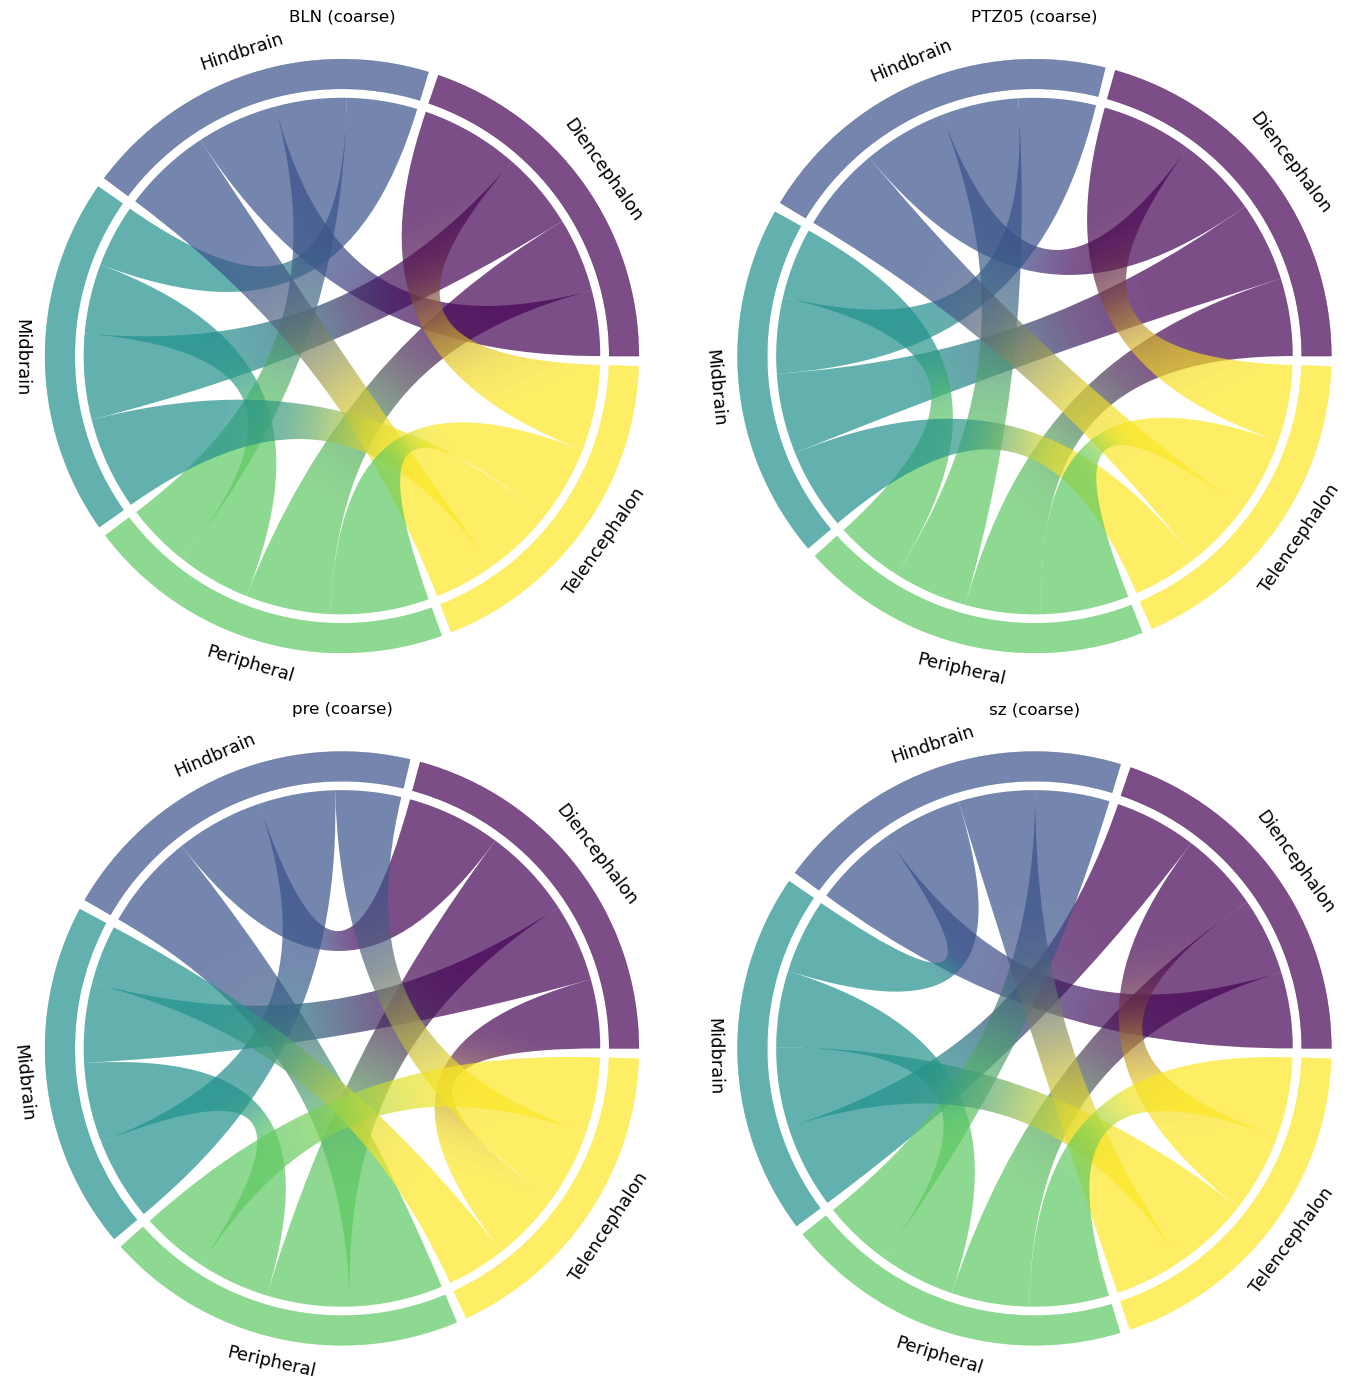

In [18]:
#COARSE GRAINED ANALYSES
#=========================

import numpy as np
import matplotlib.pyplot as plt
from mpl_chord_diagram import chord_diagram

conds = ["BLN", "PTZ05", "pre", "sz"]
scale_sel = "coarse"
drop_label = "Unspecified"
quantile_keep = 0.0   # top 80% keep, computed *globally*

# Filter once; fix node order globally
df_use = df[
    (df["scale"] == scale_sel) &
    (df["driver"] != drop_label) &
    (df["driven"] != drop_label)
].copy()

nodes = sorted(set(df_use["driver"]).union(df_use["driven"]))
idx = {n: i for i, n in enumerate(nodes)}

# ---- Global normalization + (optional) global threshold ----
rho_max = df_use["rho"].max()  # common scale for ribbon thickness
# Use same quantile across all panels (exclude self-links when computing)
global_thr = (df_use[df_use["driver"] != df_use["driven"]]["rho"]
              .quantile(quantile_keep))

# 2×2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 14), subplot_kw={'aspect': 'equal'})
axes = axes.ravel()

for ax, cond in zip(axes, conds):
    sub = df_use[df_use["cond"] == cond]
    agg = sub.groupby(["driver", "driven"], as_index=False)["rho"].mean()
    agg = agg[agg["driver"] != agg["driven"]]

    # apply *global* threshold so panels are comparable
    agg = agg[agg["rho"] >= global_thr]

    # Build adjacency, then normalize by global max so thickness is comparable
    M = np.zeros((len(nodes), len(nodes)), dtype=float)
    for _, r in agg.iterrows():
        M[idx[r["driver"]], idx[r["driven"]]] = r["rho"] / (rho_max + 1e-12)

    chord_diagram(
        M,
        names=nodes,
        use_gradient=True,
        chordwidth=0.7,
        rotate=0,
        ax=ax,
        show=False
    )
    ax.set_title(f"{cond} ({scale_sel})", fontsize=12)

plt.tight_layout()
plt.show()

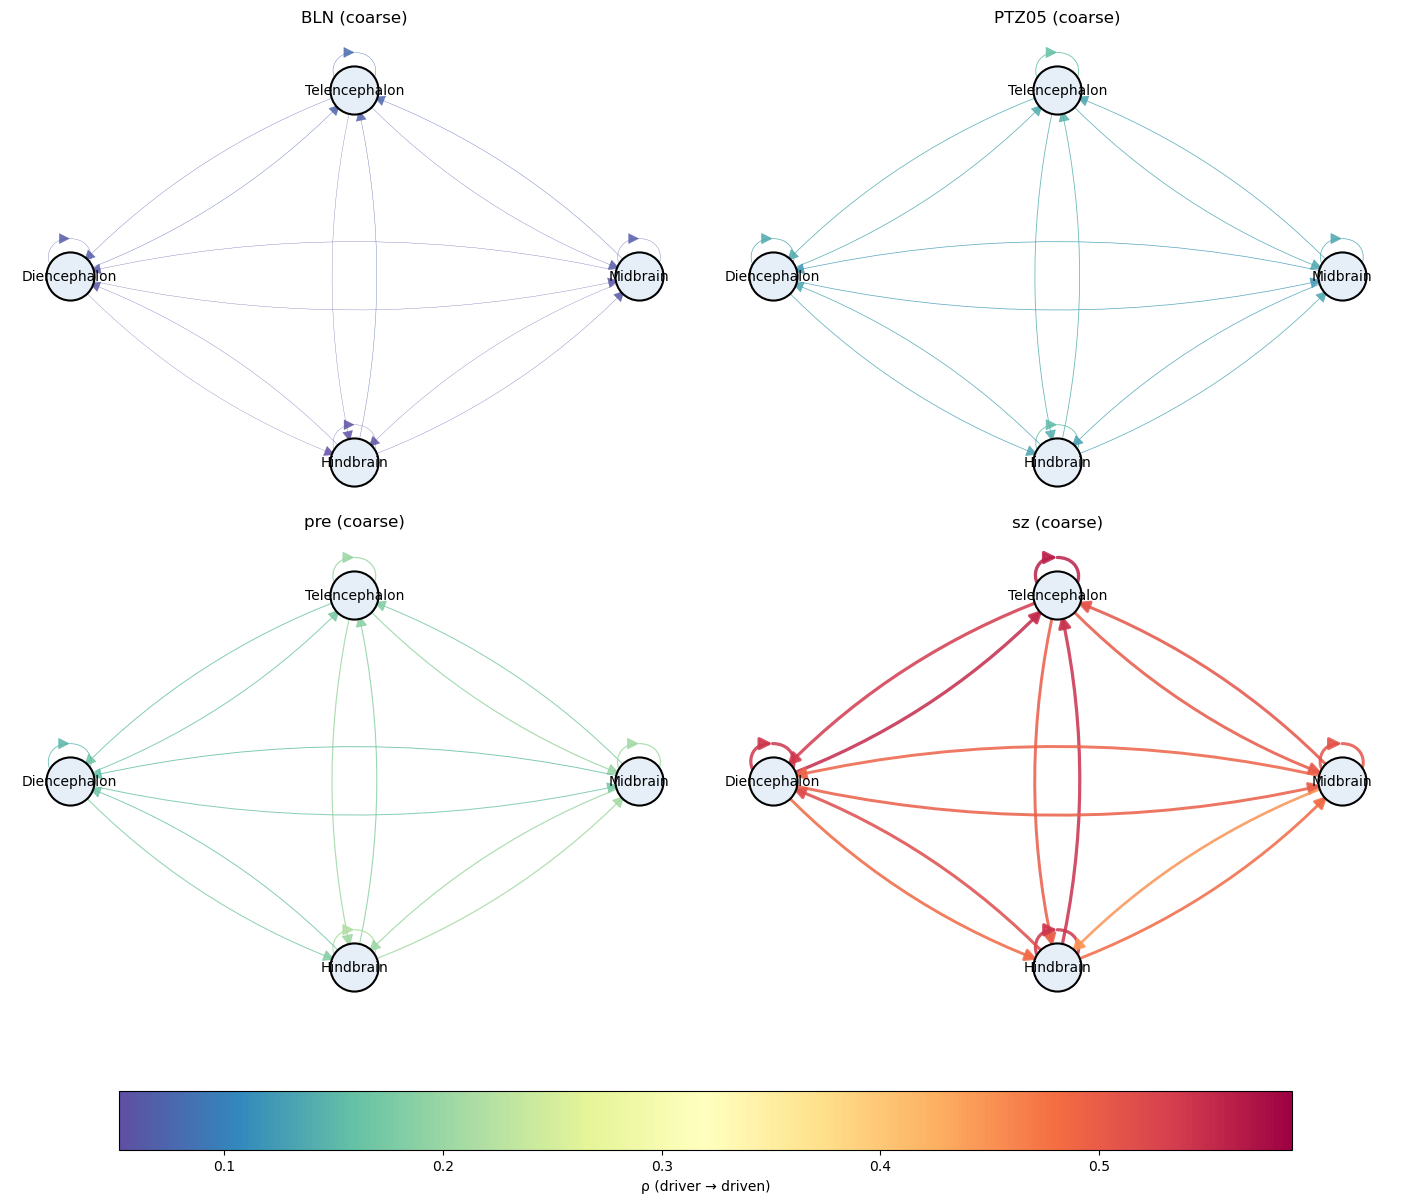

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx

conds = ["BLN", "PTZ05", "pre", "sz"]
scale_sel = "coarse"

pos_fixed = {
    "Telencephalon": (0.0,  1.0),
    "Hindbrain":     (0.0, -1.0),
    "Diencephalon": (-1.0,  0.0),
    "Midbrain":      (1.0,  0.0)}
nodes = list(pos_fixed.keys())

# global scaling
all_w = []
for c in conds:
    M = M_dict[c]
    if M.size:
        all_w.extend(M[M > 0].ravel())
if not all_w:
    all_w = [0.0]

vmin, vmax = float(np.min(all_w)), float(np.max(all_w))
if vmax <= 0:
    vmax = 1.0

cmap = plt.cm.Spectral_r
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

for ax, cond in zip(axes, conds):
    M = M_dict[cond]

    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    for i, drv in enumerate(nodes):
        for j, drn in enumerate(nodes):
            w = float(M[i, j])
            if w > 0:
                G.add_edge(drv, drn, weight=w)

    edges = list(G.edges())
    weights = np.array([G[u][v]["weight"] for u, v in edges], dtype=float)

    if weights.size:
        colors = cmap(norm(weights))
        widths = 2.5 * (weights / vmax)
    else:
        colors, widths = [], []

    # --- draw nodes (below) ---
    nx.draw_networkx_nodes(
        G, pos_fixed, ax=ax,
        node_size=1200,
        node_color="#e6eef7",
        edgecolors="black",
        linewidths=1.5
    )
    nx.draw_networkx_labels(
        G, pos_fixed, ax=ax,
        font_size=10, font_color="black"
    )

    # --- draw edges (arrowheads on top) ---
    nx.draw_networkx_edges(
        G, pos_fixed, ax=ax,
        edge_color=colors,
        width=widths.tolist(),
        arrows=True, arrowsize=18,
        arrowstyle='-|>',         # clean arrowhead
        min_target_margin=15,     # gap so arrowhead visible
        connectionstyle="arc3,rad=0.12",
        alpha=0.85
    )

    ax.set_title(f"{cond} ({scale_sel})")
    ax.set_axis_off()

# colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.06, pad=0.08)
cbar.set_label("ρ (driver → driven)")

plt.show()

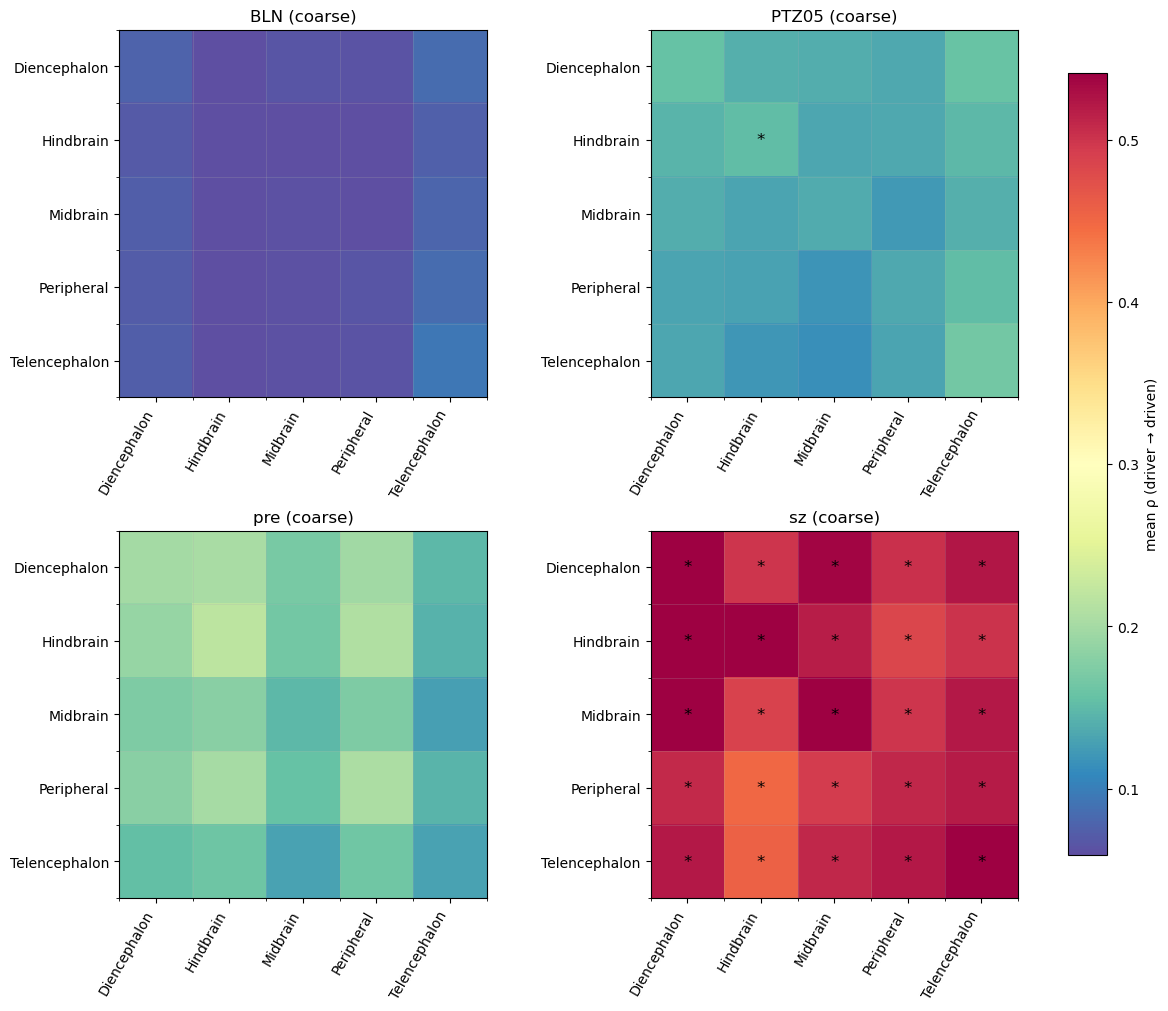

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# --- config ---
conds = ["BLN", "PTZ05", "pre", "sz"]
scale_sel = "coarse"
drop_label = "Unspecified"
alpha = 0.05
mask_diag = False

# 1) Filter and fix nodes
df_use = df[
    (df["scale"] == scale_sel) &
    (df["driver"] != drop_label) &
    (df["driven"] != drop_label)
].copy()

nodes = sorted(set(df_use["driver"]).union(df_use["driven"]))
idx = {n:i for i,n in enumerate(nodes)}
R = len(nodes)

# mean rho per dataset to form group samples per edge
g = (df_use.groupby(["name","cond","driver","driven"], as_index=False)["rho"].mean())

# Build per-condition matrices (for plotting)
M_dict = {}
for cond in conds:
    sub = (df_use[df_use["cond"] == cond]
           .groupby(["driver","driven"], as_index=False)["rho"].mean())
    M = np.zeros((R,R), float)
    for _, r in sub.iterrows():
        M[idx[r["driver"]], idx[r["driven"]]] = r["rho"]
    if mask_diag:
        np.fill_diagonal(M, np.nan)
    M_dict[cond] = M

# Common color scale
all_vals = np.concatenate([np.ravel(M_dict[c]) for c in conds])
all_vals = all_vals[~np.isnan(all_vals)]
vmin, vmax = np.percentile(all_vals, [5,95]) if all_vals.size else (0,1)

# 2) Independent-sample tests vs BLN, Bonferroni correction
tests = ["PTZ05","pre","sz"]
sig_masks = {c: np.full((R,R), False, bool) for c in tests}

for test_cond in tests:
    pmat = np.full((R,R), np.nan, float)
    incmat = np.full((R,R), np.nan, float)

    # collect all p-values first (to know number of tests for Bonferroni)
    pvals = []

    for i, drv in enumerate(nodes):
        for j, drn in enumerate(nodes):
            if mask_diag and i == j:
                continue

            bln_vals = g[(g["cond"]=="BLN") & (g["driver"]==drv) & (g["driven"]==drn)]["rho"].to_numpy()
            tst_vals = g[(g["cond"]==test_cond) & (g["driver"]==drv) & (g["driven"]==drn)]["rho"].to_numpy()

            # need a few samples in each group to test
            if len(bln_vals) < 3 or len(tst_vals) < 3:
                continue

            stat, p = mannwhitneyu(tst_vals, bln_vals, alternative="greater")
            pmat[i,j] = p
            incmat[i,j] = np.nanmean(tst_vals) - np.nanmean(bln_vals)
            pvals.append(p)

    # Bonferroni threshold uses number of actually-tested edges
    m = len(pvals)
    thr = alpha / m if m > 0 else 0.0

    # significant = p < alpha/m AND mean increase > 0
    sig = (pmat < thr) & (incmat > 0)
    sig_masks[test_cond] = np.nan_to_num(sig, nan=False)

# 3) Plot heatmaps with Bonferroni-significant increases marked
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
axes = axes.ravel()

for ax, cond in zip(axes, conds):
    M = M_dict[cond]
    im = ax.imshow(M, vmin=vmin, vmax=vmax, aspect="equal", cmap="Spectral_r")
    ax.set_title(f"{cond} ({scale_sel})")
    ax.set_xticks(range(R)); ax.set_xticklabels(nodes, rotation=60, ha="right")
    ax.set_yticks(range(R)); ax.set_yticklabels(nodes)
    ax.set_xticks(np.arange(-.5,R,1), minor=True)
    ax.set_yticks(np.arange(-.5,R,1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=0.5, alpha=0.3)

    if cond in sig_masks:
        ys, xs = np.where(sig_masks[cond])
        for y, x in zip(ys, xs):
            ax.text(x, y, "*", ha="center", va="center", fontsize=12, color="k")

cbar = fig.colorbar(im, ax=axes, shrink=0.9)
cbar.set_label("mean ρ (driver → driven)")
plt.show()


In [28]:
#figure out network visualisation figure

,name,rho_bln,rho_tst


In [27]:
#figure out in vs out hubs

,name,rho
74,PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run...,0.453822
99,PTZ-WILDTYPE-04_2photon_sess-01-6dpf_PTZ20_run...,0.541327
224,PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ20_run...,0.569837
274,PTZ-WILDTYPE-08_2photon_sess-01-6dpf_PTZ20_run...,0.394154
399,PTZ-WILDTYPE-10_2photon_sess-01-6dpf_PTZ20_run...,0.755794
474,PTZ-WILDTYPE-12_2photon_sess-01-6dpf_PTZ20_run...,0.753804
649,PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ20_run...,0.649869


In [ ]:
#figure out network topology

In [ ]:
#GRANULAR ANALYSES
#=========================

# Non-linearity & dimensionality

In [174]:
#Import packages
#---------------------------------------
import sys
import os
import glob
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import matplotlib
import kedm
import warnings
import gc
warnings.filterwarnings("ignore", category=RuntimeWarning) 

#Import your modules
#---------------------------------------
import CCM as cfn
import proc_functions as pfn

sys.path.insert(0, os.path.expanduser('~/Documents/admin_tools'))
from admin_tools import admin_functions as adfn

# Define paths
#----------------------------------------------------------------------
code = '~/Documents/empirical_dynamic_modelling'
data = '/snl/scratch25/dburrows/CCM'

%load_ext autoreload
sys.version

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'3.7.4 (default, Aug 13 2019, 20:35:49) \n[GCC 7.3.0]'

# Load in data

In [2]:
#group data
#================
#group by sample
xmap_l = np.asarray([os.path.basename(i) for i in np.sort(glob.glob(data + '/*xmap*'))])

import re
bln = xmap_l[[bool(re.search(r'(BLN|PTZ05)', i)) for i in xmap_l]]
ptz20 = xmap_l[[bool(re.search(r'(PTZ20)', i)) for i in xmap_l]]

#filter out 12 pre
s = pd.Series(ptz20)  # your series
mask = ~(s.str.contains(r'-12', na=False) & s.str.contains(r'pre', na=False))   # case-sensitive
ptz20 = ptz20[mask]

#unique sample list 
unq_l = np.append(np.unique(np.asarray([re.search(r'^(.*?_run-01)', i).group(1) for i in bln])),
          np.unique(np.asarray([''.join(re.search(r'^(.*?_run-01)(.{4})', i).groups()) for i in ptz20])))
unq_l

array(['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01',
       'PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ05_run-01',
       'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01',
       'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ05_run-01',
       'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-01',
       'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ05_run-01',
       'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_BLN_run-01',
       'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_PTZ05_run-01',
       'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_BLN_run-01',
       'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_PTZ05_run-01',
       'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_BLN_run-01',
       'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_PTZ05_run-01',
       'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_BLN_run-01',
       'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ05_run-01',
       'PTZ-WILDTYPE-15_2photon_sess-01-6dpf_BLN_run-01',
       'PTZ-WILDTYPE-15_2photon_sess-01-6dpf_PTZ05_run-01',
       'PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run-0

In [39]:
# mask data
%autoreload
#Compute fraction of cells that converge, and mean CCM in convergent cells
#==========================================================
from tqdm import tqdm

#parameters
n_int = 3 #expected interval files
int_l=[1.2, 1.4, 1.8] #expected intervals - make sure numbers are complete as in string! 
# -0.2 - i.e. allow a single negative value with <20% of the mean positive increase, to be convergent
ratio_val = -0.2 

results = []
# Loop through each unique base name
for curr in tqdm(unq_l, desc='Processing CCM files'):
    curr_l = glob.glob(f'{data}/{curr}*xmap*')
    og, mask, conv_arr = pfn.conv_check(curr_l=curr_l, n_int=n_int, int_l=int_l, ratio_val=ratio_val)
    np.save(f'{data}/{curr}_xmap_mask.npy', mask)

Processing CCM files: 100%|████████████████████████████████████████████████████████████████████████████████████████| 28/28 [06:57<00:00, 14.92s/it]


In [26]:
%autoreload
#load mask, trace & coords
#===============================
trace_l = np.sort(glob.glob(f'{data}/*regtrace*'))
xmap_l = np.sort(glob.glob(f'{data}/*_CCMxmap*'))
mask_l = np.sort(glob.glob(f'{data}/*mask*'))
coord_l = np.sort(glob.glob(f'{data}/*labcoord*'))

#load current into dic
dic = cfn.xtr(mask_l[0])
dic

{'name': 'PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01',
 'trace': array([[1101.0016   ,  375.2699   ,  160.53424  , ...,  563.22595  ,
          127.223816 ,  208.07672  ],
        [ 454.70795  , 1038.5254   ,  936.5166   , ...,  417.1315   ,
          353.54297  ,  175.36679  ],
        [   1.2036324,  610.8864   ,   23.124939 , ...,   86.47761  ,
          347.2641   ,   28.184055 ],
        ...,
        [ 151.80298  ,   44.495804 ,    1.4848621, ...,   79.7669   ,
           19.013315 ,  224.81856  ],
        [  10.489203 ,    4.8878937,   81.60853  , ...,   20.048714 ,
           11.057799 ,   17.846321 ],
        [   9.782074 ,   33.105247 ,  475.08185  , ...,   32.403248 ,
          157.73413  ,   37.58297  ]], dtype=float32),
 'coord': array([['355.94736842105266', '435.0', '97.52631578947368',
         'Optic tectum - stratum periventriculare', 'Midbrain'],
        ['409.8125', '569.8125', '132.25', 'Rhombomere 3 - Dorsolateral',
         'Hindbrain'],
        ['459.375', '

In [ ]:
#directionality
#rows = each cell is the effects of the current row
#columns = each cell is the causes of the current column
#(ie. cell xy = to what extent does x cause y; cell yx = to what extent does y cause x). 

# Coarse network analysis

In [28]:
%autoreload
mask = dic['mask']
xmap = dic['xmap']
labels = dic['coord'][:,3]
regions, xmap_m, std_m, conv_m = cfn.ccm_region(mask=mask, xmap=xmap, labels=labels)

In [29]:
dic

{'name': 'PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01',
 'trace': array([[1101.0016   ,  375.2699   ,  160.53424  , ...,  563.22595  ,
          127.223816 ,  208.07672  ],
        [ 454.70795  , 1038.5254   ,  936.5166   , ...,  417.1315   ,
          353.54297  ,  175.36679  ],
        [   1.2036324,  610.8864   ,   23.124939 , ...,   86.47761  ,
          347.2641   ,   28.184055 ],
        ...,
        [ 151.80298  ,   44.495804 ,    1.4848621, ...,   79.7669   ,
           19.013315 ,  224.81856  ],
        [  10.489203 ,    4.8878937,   81.60853  , ...,   20.048714 ,
           11.057799 ,   17.846321 ],
        [   9.782074 ,   33.105247 ,  475.08185  , ...,   32.403248 ,
          157.73413  ,   37.58297  ]], dtype=float32),
 'coord': array([['355.94736842105266', '435.0', '97.52631578947368',
         'Optic tectum - stratum periventriculare', 'Midbrain'],
        ['409.8125', '569.8125', '132.25', 'Rhombomere 3 - Dorsolateral',
         'Hindbrain'],
        ['459.375', '

In [323]:
%autoreload
ccm_region?

# Non-linearity & dimensionality

In [197]:
%autoreload
#extract E/rhodiff per region + condition
#=======================================
fin = pd.DataFrame()
for data in tqdm(mask_l):
    dic = cfn.xtr(data)
    
    df=pd.DataFrame({'E':dic['E'], 'coarse':dic['coord'][:,4], 'gran':dic['coord'][:,3]})
    #E into df
    coarse = df.drop(columns='gran').groupby(['coarse']).mean().reset_index().rename(columns={"coarse": "region"}).assign(label="coarse")
    gran = df.drop(columns='coarse').groupby(['gran']).mean().reset_index().rename(columns={"gran": "region"}).assign(label="gran")
    comb = pd.concat([coarse,gran])

    if '_sz_' in data or '_pre_' in data:
        cond = data.split('_')[-2]
    else:
        cond = data.split('_')[-3]

    comb['name'] = cond
    comb['id'] = os.path.basename(data)
    pd.concat([fin,comb])
    
    fin.to_csv(f'{data_path}/E_region.csv')

KeyboardInterrupt: 

In [ ]:
#rho diff run


In [ ]:
#visualise across regions//conditions

In [ ]:
#visualise linear vs non-linear networks

#what are you trying to visualise? 